# Análisis y Predicción de Retraso de Vuelos

En este notebook vamos a explorar un dataset de vuelos, analizar cuáles son los principales factores que influyen en los retrasos y, finalmente, entrenar un modelo de Machine Learning que nos permita predecir el tiempo de espera. Para empezar, importamos `pandas` y cargamos los datos.

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('flights.csv')

## 1. Exploración Inicial de los Datos

Demos un primer vistazo a la estructura de nuestro dataset. Veremos qué tamaño tiene, las primeras filas para entender el formato, el tipo de dato de cada columna y un breve resumen estadístico.

In [3]:
data.shape

(71175, 11)

In [4]:
data.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [6]:
data.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [7]:
data.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


## 2. Análisis Exploratorio de Datos (EDA)

Vamos a visualizar cómo se comporta el retraso promedio dependiendo de la aerolínea, si el vuelo es tipo Schengen o no, si es día feriado y el tipo de avión. Estas visualizaciones son clave para entender qué variables tienen mayor impacto.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns



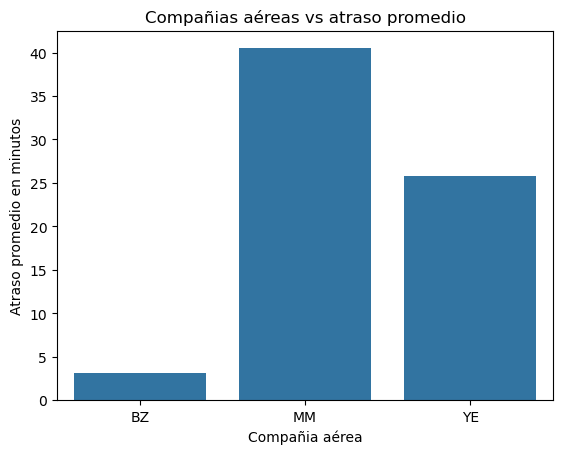

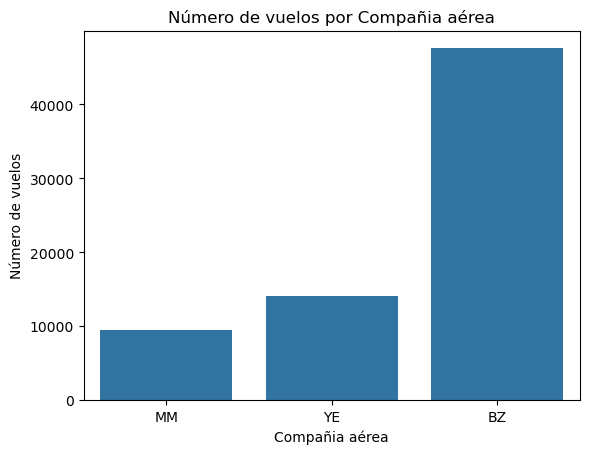

In [9]:
avg_delay = data.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline', y='delay', data=avg_delay)
plt.title('Compañias aéreas vs atraso promedio')
plt.xlabel('Compañia aérea')
plt.ylabel('Atraso promedio en minutos')
plt.show()



sns.countplot(data, x='airline')
plt.title('Número de vuelos por Compañia aérea')
plt.xlabel('Compañia aérea')
plt.ylabel('Número de vuelos')
plt.show()

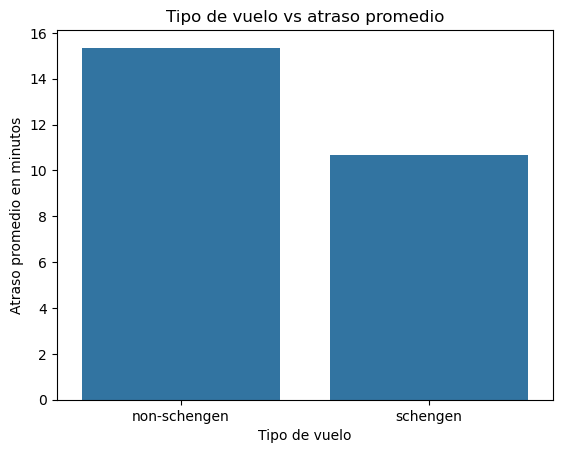

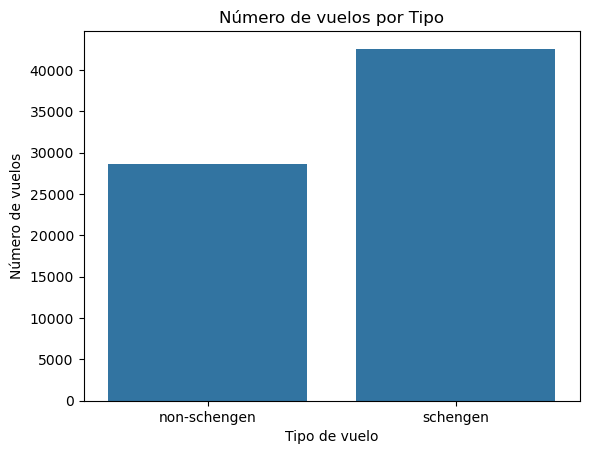

In [10]:
avg_delay = data.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen', y='delay', data=avg_delay)
plt.title('Tipo de vuelo vs atraso promedio')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Atraso promedio en minutos')
plt.show()



sns.countplot(data, x='schengen')
plt.title('Número de vuelos por Tipo')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Número de vuelos')
plt.show()

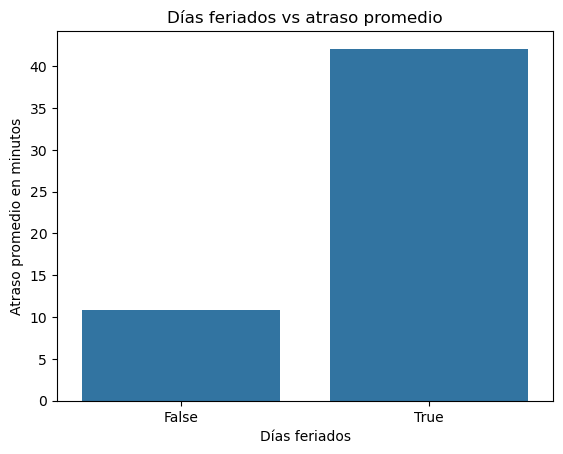

In [11]:
avg_delay = data.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday', y='delay', data=avg_delay)
plt.title('Días feriados vs atraso promedio')
plt.xlabel('Días feriados')
plt.ylabel('Atraso promedio en minutos')
plt.show()

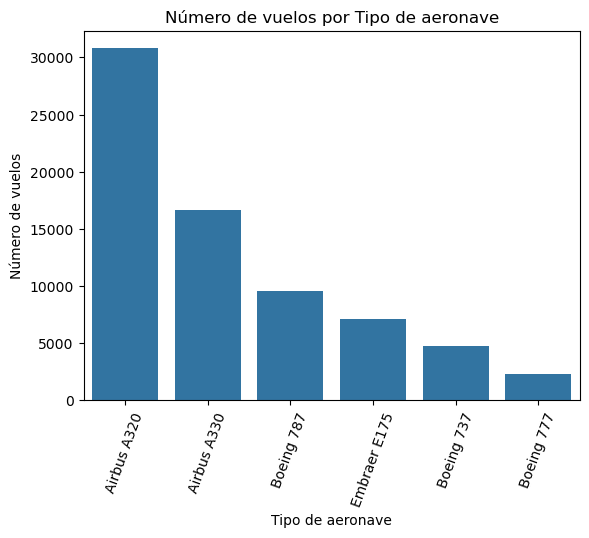

In [12]:
order = data['aircraft_type'].value_counts().index
sns.countplot(data, x='aircraft_type', order=order)
plt.title('Número de vuelos por Tipo de aeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo de aeronave')
plt.ylabel('Número de vuelos')
plt.show()

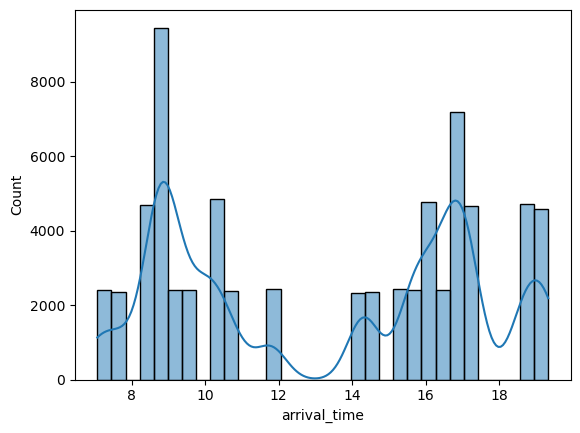

In [13]:
sns.histplot(data, x='arrival_time', kde=True);

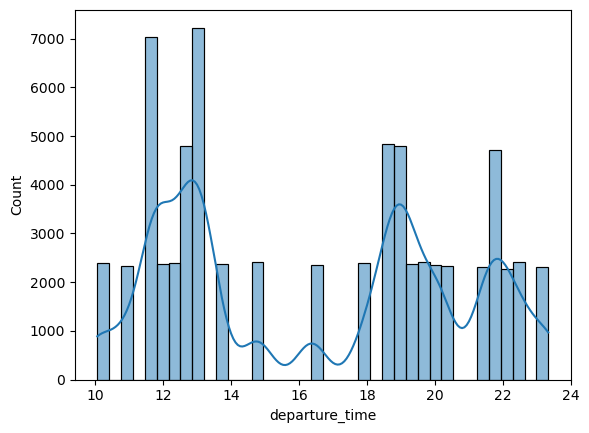

In [14]:
sns.histplot(data, x='departure_time', kde=True);

Revisemos la distribución de la variable objetivo (**delay**). Un boxplot y un histograma nos ayudarán a entender si los retrasos están concentrados en unos pocos minutos o si hay valores atípicos muy grandes.

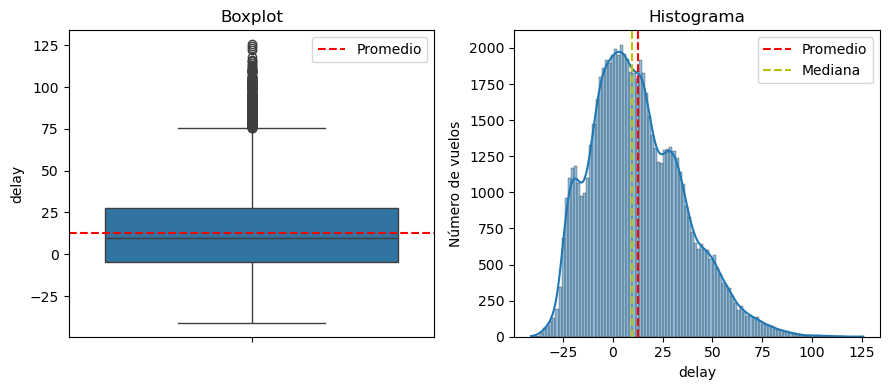

In [15]:
atraso_promedio = data['delay'].mean()
atraso_mediana = data['delay'].median()

fig, ax = plt.subplots(1,2,figsize=(9,4))

sns.boxplot(data, y='delay', ax=ax[0])
ax[0].set_title('Boxplot')
ax[0].axhline(y=atraso_promedio, color='r', linestyle='--', label='Promedio')
ax[0].legend()

sns.histplot(data, x='delay', ax=ax[1], kde=True)
plt.ylabel('Número de vuelos')
plt.grid(False)
ax[1].set_title('Histograma')
ax[1].axvline(x=atraso_promedio, color='r', linestyle='--', label='Promedio')
ax[1].axvline(x=atraso_mediana, color='y', linestyle='--', label='Mediana')
ax[1].legend()

plt.tight_layout()
plt.show()

In [16]:
data.columns

Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

## 3. Ingeniería de Características (Feature Engineering)

Podemos sacar más provecho de los datos creando nuevas variables. Con el día del año (`day`) y el año (`year`) se puede armar una fecha completa, lo cual permite saber qué día de la semana es y si cae en fin de semana.

In [17]:
data['date'] = data['year'].astype(str) + '-' + (data['day']+ 1).astype(str)
data['date'] = pd.to_datetime(data['date'], format='%Y-%j')

In [18]:
data.sample(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
37021,8,BZ,Airbus A320,schengen,ZQO,15.729617,18.729617,278,2016,False,-1.432451,2016-10-05
61287,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,70,2021,False,16.141771,2021-03-12


In [19]:
data['is_weekend'] = data['date'].dt.weekday.isin([5,6])
data['day_name'] = data['date'].dt.day_name()

In [20]:
data.sample(3)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
52037,2,BZ,Airbus A320,schengen,ZQO,19.196804,22.196804,184,2019,False,-1.856214,2019-07-04,False,Thursday
51625,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,156,2019,False,-11.994484,2019-06-06,False,Thursday
67886,4,BZ,Airbus A330,schengen,TCY,11.781391,14.781391,145,2022,False,-12.509738,2022-05-26,False,Thursday


In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  object        
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  bool          
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  bool          
 13  day_name        71175 non-null  object        
dtypes: bool(2), datetime64[ns](1), float64(3), int64(3), o

## 4. Preprocesamiento de Datos

Para que los modelos de Machine Learning funcionen correctamente, necesitamos convertir las variables categóricas o booleanas a un formato numérico. Mapeamos valores simples y usamos *One-Hot Encoding* para las columnas que tienen varias categorías.

In [22]:
import warnings
warnings.filterwarnings('ignore')

In [23]:
data['schengen'] = data['schengen'].replace({'non-schengen':0, 'schengen':1})
data['is_holiday'] = data['is_holiday'].replace({False:0, 'True':1})
data['is_weekend'] = data['is_weekend'].replace({False:0, 'True':1})

In [24]:
data.head(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
0,26,MM,Airbus A320,0,TCY,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,Friday
1,10,YE,Airbus A320,0,TCY,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,Friday


In [25]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']

one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), categoricas),
    remainder='passthrough',
    verbose_feature_names_out=False
)

data = one_hot_enc.fit_transform(data)
data = pd.DataFrame(data, columns=one_hot_enc.get_feature_names_out())

data
data

,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,aircraft_type_Boeing 737,aircraft_type_Boeing 777,aircraft_type_Boeing 787,aircraft_type_Embraer E175,origin_AUZ,...,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3,1,18.635384,22.635384,364,2022,True,25.677277,2022-12-31,True
71171,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,17,0,16.718722,21.718722,364,2022,True,52.624348,2022-12-31,True
71172,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,7,1,8.564949,13.564949,364,2022,True,56.16708,2022-12-31,True
71173,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5,1,9.344097,12.344097,364,2022,True,56.758844,2022-12-31,True


In [26]:
data[['arrival_time', 'departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [27]:
df = data.drop(columns= ['flight_id', 'departure_time', 'day', 'year', 'date'])
df

,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,aircraft_type_Boeing 737,aircraft_type_Boeing 777,aircraft_type_Boeing 787,aircraft_type_Embraer E175,origin_AUZ,...,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday,schengen,arrival_time,is_holiday,delay,is_weekend
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,8.885071,0,70.205981,0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,8.939996,0,38.484609,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1,18.635384,0,2.388305,0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,15.967963,0,19.138491,0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,16.571894,0,15.016271,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1,18.635384,True,25.677277,True
71171,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0,16.718722,True,52.624348,True
71172,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1,8.564949,True,56.16708,True
71173,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1,9.344097,True,56.758844,True


## 5. Preparación para Modelar

Con el dataset listo y limpio, separamos nuestras variables predictoras (`X`) de nuestra variable objetivo (`delay` en `y`). Luego, dividimos los datos en conjunto de entrenamiento y prueba.

In [28]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

X = df.drop(columns='delay', axis=1)
y = df['delay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 6. Modelo Base (Baseline)

Siempre es buena práctica tener un modelo base que nos sirva de punto de referencia. Cualquier modelo que entrenemos debe superar las métricas de este baseline.

In [29]:
baseline = DummyRegressor()
baseline.fit(X_train, y_train)

DummyRegressor()

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_dummy = baseline.predict(X_test)

def calcular_regresion(y_test, y_pred):
    rmse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    metricas = {
        'RMSE': round(rmse**(1/2),4),
        'MAE': round(mae, 4),
        'R2': round(r2, 4)
    }
    return metricas

In [31]:
resultados_baseline = calcular_regresion(y_test, y_pred_dummy)
resultados_baseline

{'RMSE': 23.1612, 'MAE': 18.5646, 'R2': -0.0}

## 7. Random Forest Regressor

Probamos un primer modelo real usando Random Forest. Calculamos las métricas (RMSE, MAE, R2) y usamos *Yellowbrick* para visualizar tanto el error de predicción como los residuos.

In [32]:
from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)
y_pred_rf = modelo.predict(X_test)
resultados_rf = calcular_regresion(y_test, y_pred_rf)
resultados_rf

{'RMSE': 13.7479, 'MAE': 11.0262, 'R2': 0.6477}

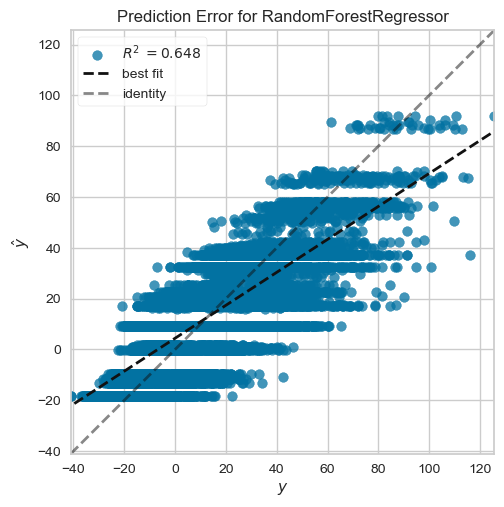

In [33]:
from yellowbrick.regressor import prediction_error

visualizer = prediction_error(modelo, X_train, y_train, X_test, y_test)

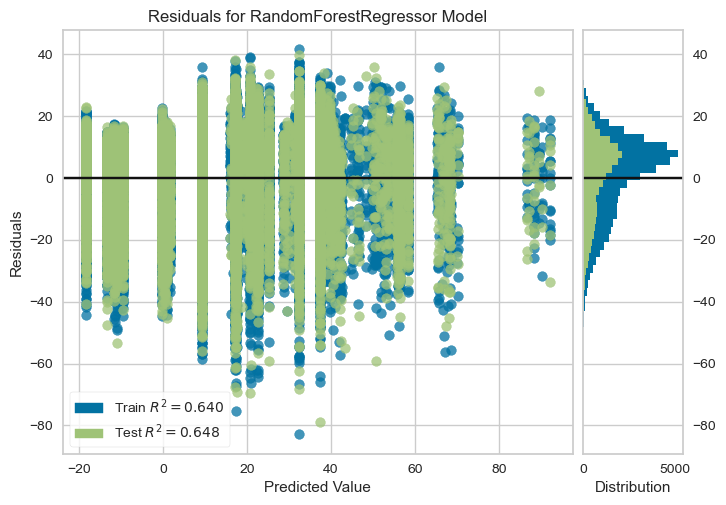

In [34]:
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(modelo, X_train, y_train, X_test, y_test)

Aplicamos validación cruzada (*Cross Validation*) para asegurarnos de que el rendimiento del modelo sea consistente y no estemos sobreajustando a una partición específica de los datos.

In [35]:
from sklearn.model_selection import KFold, cross_validate

scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2',
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(modelo, X_train, y_train, scoring=scoring, cv=cv)

In [36]:
cv_results

{'fit_time': array([6.10644269, 5.56720781, 5.76346374, 5.03172398, 5.02500081]),
 'score_time': array([0.14713693, 0.21212697, 0.17825556, 0.12834811, 0.10961986]),
 'test_RMSE': array([-13.76989748, -13.86928373, -13.96807668, -13.85347402,
        -13.98953528]),
 'test_MAE': array([-11.03252135, -11.13534968, -11.2094657 , -11.14503717,
        -11.25775565]),
 'test_R2': array([0.64559466, 0.63745663, 0.63523823, 0.64089302, 0.63441267])}

In [37]:
len(df.columns)

31

## 8. Selección de Características

Veamos cuáles son las columnas que más le importan al modelo para hacer las predicciones. La idea es intentar reducir la cantidad de variables sin perder mucho poder predictivo, haciendo el modelo más rápido y simple.

In [38]:
importances = modelo.feature_importances_
feature_importances = pd.DataFrame({'Feautures': X.columns, 'Importances': (importances*100).round(2)}).sort_values('Importances', ascending=False)
feature_importances

,Feautures,Importances
0,airline_BZ,53.03
28,is_holiday,14.59
3,aircraft_type_Airbus A320,10.07
4,aircraft_type_Airbus A330,5.76
8,aircraft_type_Embraer E175,4.59
27,arrival_time,3.64
7,aircraft_type_Boeing 787,2.51
16,origin_TCY,2.23
11,origin_CSF,1.64
15,origin_PUA,0.99


In [39]:
resultados = pd.DataFrame(index=['RMSE', 'MAE', 'R2'])
model_features = RandomForestRegressor(max_depth=5, random_state=42)
ct_features = [i if i != 0 else 1 for i in range(0,35,5)]

for i in ct_features:
    selected_features = feature_importances['Feautures'].values[:i]
    X_train_sel = X_train[selected_features]
    X_test_sel = X_test[selected_features]
    model_features.fit(X_train_sel, y_train)
    y_pred_rf = model_features.predict(X_test_sel)
    metricas = calcular_regresion(y_test, y_pred_rf)
    resultados[i] = list(metricas.values())
    
resultados


,1,5,10,15,20,25,30
RMSE,18.8331,15.1564,13.7587,13.7497,13.7472,13.7473,13.7479
MAE,14.9620,12.0605,11.0422,11.0285,11.0264,11.0259,11.0262
R2,0.3388,0.5718,0.6471,0.6476,0.6477,0.6477,0.6477


In [40]:
selected_features = feature_importances['Feautures'].values[:13]
X_selected_features= X[selected_features]
X_selected_features

,airline_BZ,is_holiday,aircraft_type_Airbus A320,aircraft_type_Airbus A330,aircraft_type_Embraer E175,arrival_time,aircraft_type_Boeing 787,origin_TCY,origin_CSF,origin_PUA,origin_TZF,day_name_Friday,aircraft_type_Boeing 737
0,0.0,0,1.0,0.0,0.0,8.885071,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0,1.0,0.0,0.0,8.939996,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0,0.0,0.0,1.0,18.635384,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.0,0,0.0,1.0,0.0,15.967963,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0,0.0,1.0,0.0,16.571894,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1.0,True,0.0,0.0,1.0,18.635384,0.0,0.0,0.0,0.0,1.0,0.0,0.0
71171,1.0,True,0.0,1.0,0.0,16.718722,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71172,0.0,True,0.0,0.0,0.0,8.564949,1.0,0.0,0.0,0.0,1.0,0.0,0.0
71173,1.0,True,1.0,0.0,0.0,9.344097,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_selected_features,y,random_state=42)

## 9. Optimización de Hiperparámetros

Con un subconjunto de las variables más importantes, hacemos una búsqueda (*GridSearchCV*) para probar distintas combinaciones de parámetros y encontrar la configuración óptima de nuestro árbol.

In [42]:
param_grid = {
    'max_depth': [5,10,15],
    'min_samples_leaf': [1,2,3],
    'min_samples_split': [2,4,6],
    'n_estimators': [100,150,200]
}

In [43]:
from sklearn.model_selection import GridSearchCV

cv = KFold(n_splits=5, shuffle=True, random_state=42)
model_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=param_grid, scoring='r2',cv=cv, n_jobs=-1)

In [ ]:
model_grid.fit(X_train, y_train)

In [ ]:
model_grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 200}

In [ ]:
y_pred_grid = model_grid.predict(X_test)
metricas_model_grid = calcular_regresion(y_test, y_pred_grid)
metricas_model_grid

{'RMSE': 13.2308, 'MAE': 10.6295, 'R2': 0.6754}

In [ ]:
resultados['modelo_grid'] = list(metricas_model_grid.values())
resultados

,1,5,10,15,20,25,30,modelo_grid
RMSE,18.8331,15.1564,13.7587,13.7497,13.7472,13.7473,13.7479,13.2308
MAE,14.9620,12.0605,11.0422,11.0285,11.0264,11.0259,11.0262,10.6295
R2,0.3388,0.5718,0.6471,0.6476,0.6477,0.6477,0.6477,0.6754


## 10. Guardar el Modelo (Serialización)

Una vez que tenemos nuestro mejor modelo elegido, lo guardamos o "empaquetamos" con la librería `pickle`. De esta forma podemos llevarlo a producción y reusarlo después sin tener que entrenar todo de nuevo.

In [ ]:
import pickle

try:
    with open('champion.pkl', 'wb') as file:
        pickle.dump(model_grid.best_estimator_,file)
        print('Modelo serializado con éxito')
except Exception as e:
    print('Se presentó un error al almacenar el modelo', str(e))

Modelo serializado con éxito


Por último, creamos una nueva muestra de datos de un vuelo ficticio para probar que el modelo guardado y recién cargado puede predecir correctamente el retraso esperado.

In [ ]:
nueva_muestra = [0.0, 10.8941, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [ ]:
try:
    with open('champion.pkl', 'rb') as file:
        model = pickle.load(file)
    print("¡Modelo cargado con éxito!")
except Exception as e:
    print("Ocurrió un error al cargar el modelo:", str(e))

¡Modelo cargado con éxito!


In [ ]:
model.predict([nueva_muestra])

array([48.40436867])